In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os


feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from PROPS_EV.calculateEVS import *
from BACKTEST.backtest import *
from MODELS.Models import *

In [2]:
model = joblib.load('../MODELS/Models/xgbModel.pkl')
features = joblib.load('../MODELS/Models/top_features.pkl')

In [3]:
pd.set_option('display.max_columns', None)
eplison = 0.000001

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * (s25['MIN_ROLLING_AVG_5'] + eplison)
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * (s24['MIN_ROLLING_AVG_5'] + eplison)

df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['CATEGORY'] == 'player_points') & (backtestData['BOOKMAKER'] == 'prizepicks')]
backtestData

C:\Users\alexg\AppData\Local\Temp\ipykernel_27044\234261984.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
0,0,0,0,Miles McBride,player_points,prizepicks,under,8.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
3,3,3,3,Jayson Tatum,player_points,prizepicks,over,26.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
4,4,4,4,Jayson Tatum,player_points,prizepicks,under,26.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
5,5,5,5,Jalen Brunson,player_points,prizepicks,over,27.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
6,6,6,6,Jalen Brunson,player_points,prizepicks,under,27.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198078,198078,198078,119117,Blake Wesley,player_points,prizepicks,under,9.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,-108.0,under
198083,198083,198083,119122,Malaki Branham,player_points,prizepicks,over,11.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,12.5,100.0,over
198089,198089,198089,119128,Malaki Branham,player_points,prizepicks,under,11.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,12.5,100.0,under
198095,198095,198095,119134,Garrett Temple,player_points,prizepicks,under,9.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,-115.0,under


In [5]:
results = backtestPrizePicksPairs(df, backtestData, '2025-03-21', model, features, edge_threshold=4.5, top_n=10, simulations=10000)
results

Processing pairs...


,player1,player2,side1,side2,model_side1,model_side2,line1,line2,pred1,pred2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,probability,date
0,A.J. Lawson,Bronny James,over,over,UNDER,OVER,10.5,6.5,3.07,10.99,0,17,-7.43,4.49,1,1,0,1,1.873,0.9577,2025-03-21
1,A.J. Lawson,Gabe Vincent,over,over,UNDER,UNDER,10.5,14.5,3.07,7.18,0,9,-7.43,-7.32,1,1,1,1,1.869,0.9564,2025-03-21
2,A.J. Lawson,Austin Reaves,over,over,UNDER,UNDER,10.5,30.5,3.07,21.94,0,22,-7.43,-8.56,1,1,1,1,1.712,0.9040,2025-03-21
3,AJ Johnson,Bronny James,under,over,OVER,OVER,8.5,6.5,13.69,10.99,12,17,5.19,4.49,1,1,0,1,1.683,0.8943,2025-03-21
4,AJ Johnson,Gabe Vincent,under,over,OVER,UNDER,8.5,14.5,13.69,7.18,12,9,5.19,-7.32,1,1,1,1,1.679,0.8931,2025-03-21
5,Bronny James,Jordan Poole,over,under,OVER,OVER,6.5,14.0,10.99,20.84,17,2,4.49,6.84,1,0,0,0,1.640,0.8801,2025-03-21
6,Gabe Vincent,Jordan Poole,over,under,UNDER,OVER,14.5,14.0,7.18,20.84,9,2,-7.32,6.84,1,0,1,0,1.637,0.8789,2025-03-21
7,A.J. Lawson,AJ Johnson,over,under,UNDER,OVER,10.5,8.5,3.07,13.69,0,12,-7.43,5.19,1,1,1,1,1.635,0.8784,2025-03-21
8,Bronny James,Julian Phillips,over,over,OVER,OVER,6.5,6.5,10.99,8.84,17,2,4.49,2.34,1,0,0,0,1.605,0.8683,2025-03-21
9,Gabe Vincent,Julian Phillips,over,over,UNDER,OVER,14.5,6.5,7.18,8.84,9,2,-7.32,2.34,1,0,0,0,1.602,0.8672,2025-03-21


In [6]:
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['pair_recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['pair_won'].sum()
        rec_win_rate = recommended['pair_won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")


--- All Bets ---
Total: 10, Wins: 6, Win Rate: 60.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 5, Wins: 4, Win Rate: 80.00%


In [7]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPrizePicksPairs(df, backtestData, date, model, features, edge_threshold=5, top_n=10, simulations=10000)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-24... 2/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-25... 3/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-26... 4/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-27... 5/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-28... 6/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-29... 7/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-30... 8/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-31... 9/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-01... 10/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-02... 11/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-03... 12/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-04... 13/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-06... 14/162
Processing pair

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,410
   Wins: 665
   Hit Rate: 47.16%
   Total Profit: $2,925.00
   Total Staked: $7,050.00
   ROI: 41.49%
   Volatility: $43.30
   Max Drawdown: $-195.00
   Sharpe Ratio: 5.689

 RECOMMENDED BETS ANALYSIS (Edge > 5):
   Total Bets: 424
   Wins: 235
   Hit Rate: 55.42%
   Total Profit: $1,405.00
   Total Staked: $2,120.00
   ROI: 66.27%
   Volatility: $26.97
   Max Drawdown: $-110.00
   Sharpe Ratio: 5.061


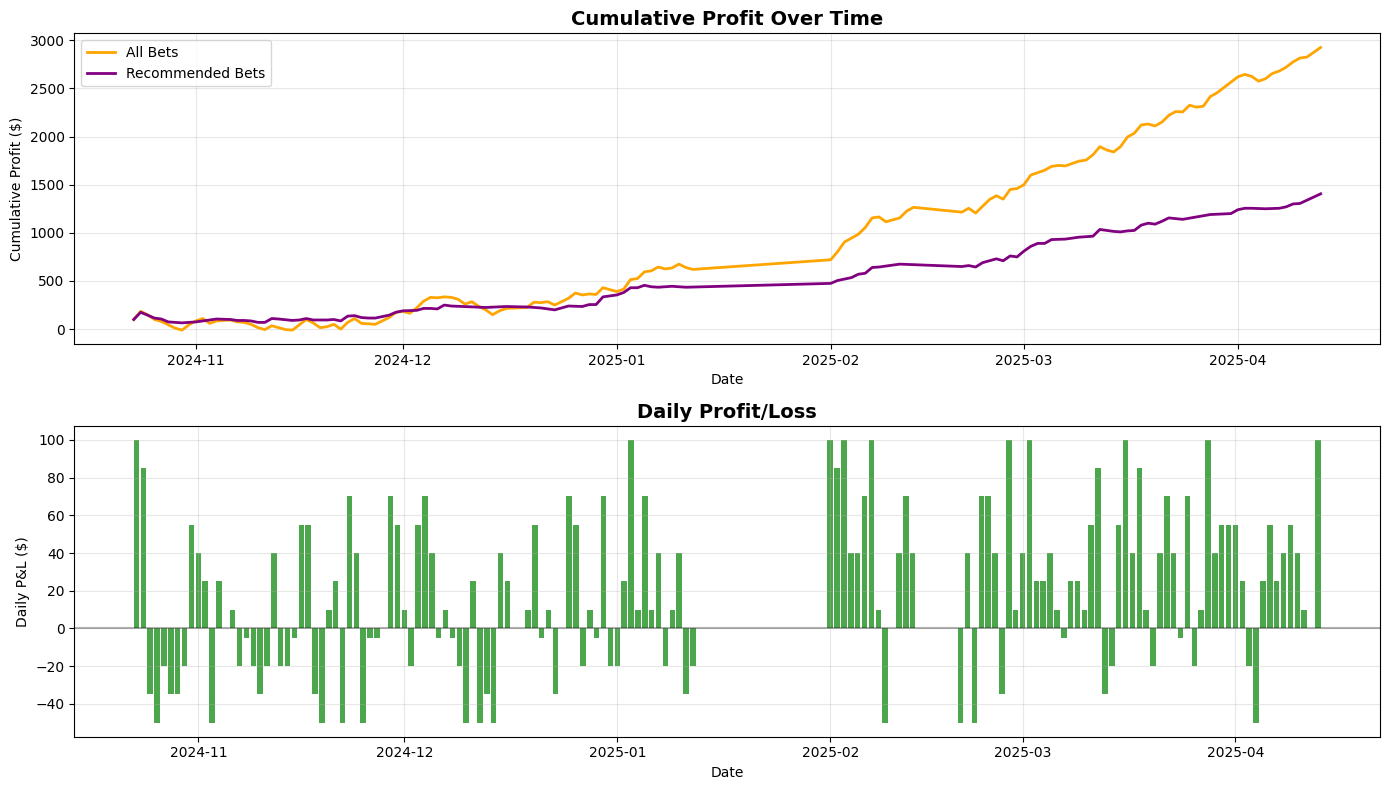

In [10]:
edge = 5
# Calculate metrics for all bets
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [9]:
final_results.to_csv('pairs5edgePrizepicks.csv')